(4578, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4578 entries, 0 to 4577
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         4578 non-null   int64  
 1   Order ID       4578 non-null   object 
 2   Order Date     4578 non-null   object 
 3   Ship Date      4578 non-null   object 
 4   Ship Mode      4578 non-null   object 
 5   Customer ID    4578 non-null   object 
 6   Customer Name  4578 non-null   object 
 7   Segment        4578 non-null   object 
 8   Country        4578 non-null   object 
 9   City           4578 non-null   object 
 10  State          4578 non-null   object 
 11  Postal Code    4578 non-null   int64  
 12  Region         4578 non-null   object 
 13  Product ID     4578 non-null   object 
 14  Category       4578 non-null   object 
 15  Sub-Category   4578 non-null   object 
 16  Product Name   4578 non-null   object 
 17  Sales          4578 non-null   float64
 1

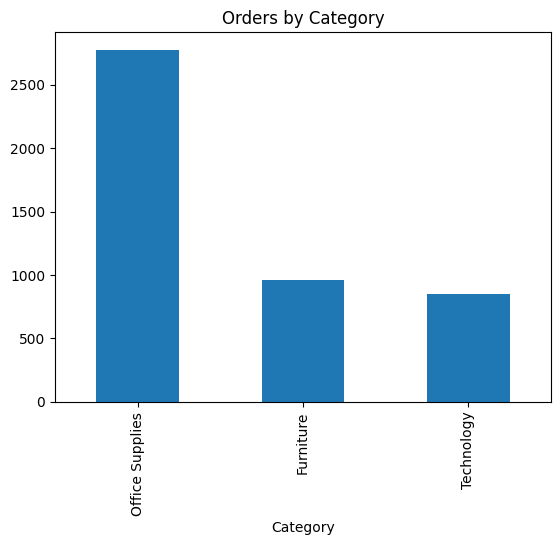

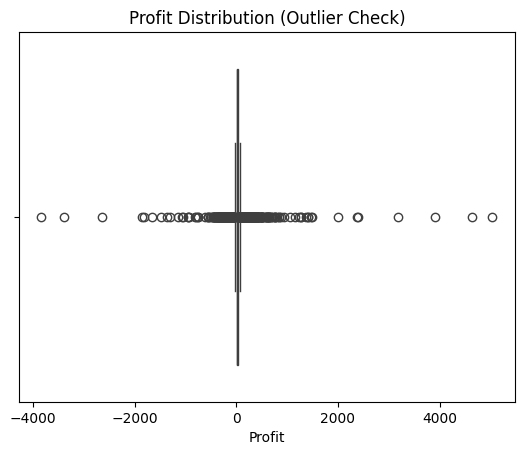

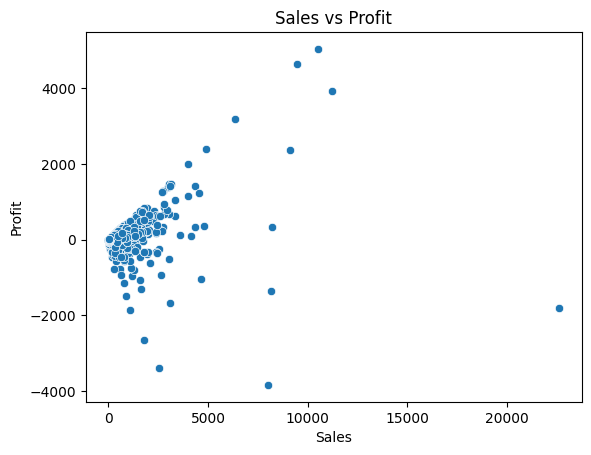

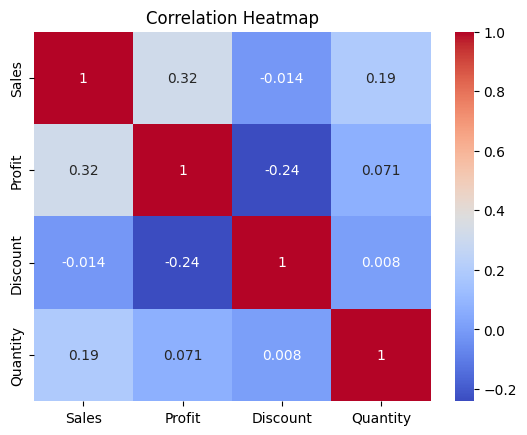

T-test p-value: 3.787916389720356e-30


In [2]:
!pip install pandas matplotlib seaborn scipy -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Category"].value_counts().plot(kind="bar", title="Orders by Category")
plt.show()

sns.boxplot(x=df["Profit"])
plt.title("Profit Distribution (Outlier Check)")
plt.show()

sns.scatterplot(x="Sales", y="Profit", data=df)
plt.title("Sales vs Profit")
plt.show()

corr = df[["Sales", "Profit", "Discount", "Quantity"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

high_discount = df[df["Discount"] > 0.2]["Profit"]
low_discount = df[df["Discount"] <= 0.2]["Profit"]
t_stat, p_val = stats.ttest_ind(high_discount, low_discount, equal_var=False)
print(f"T-test p-value: {p_val}")

In [3]:
import sqlite3

conn = sqlite3.connect(":memory:")
df.to_sql("orders", conn, index=False, if_exists="replace")

query = """
SELECT Category, ROUND(SUM(Profit),2) as total_profit, ROUND(AVG(Discount),2) as avg_discount
FROM orders
GROUP BY Category
ORDER BY total_profit DESC
"""
result = pd.read_sql(query, conn)
print(result)

          Category  total_profit  avg_discount
0       Technology      58012.37          0.13
1  Office Supplies      54078.27          0.16
2        Furniture       7910.07          0.17
